# 1. Основной код поиска совпадений между пролетом спутника и областью грозового кластера

In [1]:
# Подключение библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyproj import Transformer
import xarray as xr
import datetime as dt
import os
from math import radians, cos, sin, asin, sqrt

In [2]:
# Входные данные
thunderbolts_npz_in = 'C:/Users/Maks/Desktop/Jupyter/2012_thunderbolts_clastered.npz'
thunderbolts_hdf_out = '2012_thunderbolts_clastered.h5'
satellite_directory = 'C:/Users/Maks/Desktop/Jupyter/satellite data'
output_filtered_satellite_dir = "C:/Users/Maks/Desktop/Jupyter/output_filtered_satellite_data"
output_full_data_dir = "C:/Users/Maks/Desktop/Jupyter/output_full_data"
interval = 15 # 15 минутный интервал вокруг грозового разряда и вокруг момента совпадения

In [3]:
# Преобразование из формата .npz в .hdf, удаление лишних данных, установление даты в качестве индекса
data = np.load(thunderbolts_npz_in)
data_npz = pd.DataFrame(data['strikes']).drop('tail', axis=1).set_index('date')
data_npz.to_hdf(thunderbolts_hdf_out, key='strikes', mode='w', complevel=9)
data_hdf = pd.read_hdf('2012_thunderbolts_clastered.h5', 'strikes')

## Выявление файлов .vec с некорректными данными (Data_OK=b'F')

In [4]:
# Выявление файлов .vec с некорректными данными (Data_OK=b'F')
files_to_delete = []
for filename in os.listdir(satellite_directory):
    file_path = os.path.join(satellite_directory, filename)
    satellite_data = xr.open_dataset(file_path, decode_timedelta=True)
    if (satellite_data['data_ok'].values == b'F').any():
        files_to_delete.append(file_path)
        print(f"Файл {filename} содержит data_ok=b'F'")
    satellite_data.close()
if len(files_to_delete) == 0:
    print("Файлов с data_ok=b'F' не найдено")

Файлов с data_ok=b'F' не найдено


## Функции

In [5]:
# Функция для расчета расстояния между двумя точками (гаверсинус)
def haversine(lon1, lat1, lon2, lat2):
    """
    Рассчитывает расстояние между двумя точками на Земле
    с использованием формулы гаверсинуса.
    """
    # Перевод градусов в радианы
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    
    # Формула гаверсинуса
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Радиус Земли в километрах
    return int(c * r)

In [6]:
# Функция удаления отдаленных разрядов и выделения области наибольшего скопления
def simple_remove_outliers(group, percentile=90, plot=False, cluster_id=None):
    if len(group) <= 5:
        # Для малых кластеров находим самую плотную группу разрядов
        if len(group) == 1:
            # Для одного разряда - минимальная область вокруг него
            lat, lon = group['lat'].iloc[0], group['lon'].iloc[0]
            fixed_span = 0.09  # 10×10 км
            bounds = (
                lat - fixed_span/2,
                lat + fixed_span/2,
                lon - fixed_span/2,
                lon + fixed_span/2
            )
        else:
            # Для 2-5 разрядов находим пару самых близких точек
            coords = group[['lat', 'lon']].values
            min_distance = float('inf')
            closest_pair = None
            # Находим две самые близкие точки
            for i in range(len(coords)):
                for j in range(i+1, len(coords)):
                    distance = np.sqrt((coords[i][0] - coords[j][0])**2 + (coords[i][1] - coords[j][1])**2)
                    if distance < min_distance:
                        min_distance = distance
                        closest_pair = (coords[i], coords[j])
            if closest_pair:
                # Центр между двумя самыми близкими точками
                lat_center = (closest_pair[0][0] + closest_pair[1][0]) / 2
                lon_center = (closest_pair[0][1] + closest_pair[1][1]) / 2
                # Определяем размер области на основе распределения точек
                distances_from_center = np.sqrt(
                    (group['lat'] - lat_center)**2 + (group['lon'] - lon_center)**2
                )
                # Берем 75% перцентиль расстояний + минимальный размер
                radius = max(np.percentile(distances_from_center, 75), 0.045)  # минимум 5 км
                bounds = (
                    lat_center - radius,
                    lat_center + radius,
                    lon_center - radius,
                    lon_center + radius
                )
            else:
                # Запасной вариант
                lat_center = group['lat'].mean()
                lon_center = group['lon'].mean()
                fixed_span = 0.09
                bounds = (
                    lat_center - fixed_span/2,
                    lat_center + fixed_span/2,
                    lon_center - fixed_span/2,
                    lon_center + fixed_span/2
                )
    else:
        # Для больших кластеров - обычная фильтрация по перцентилям
        cut_percent = (100 - percentile) / 2
        lat_min = np.percentile(group['lat'], cut_percent)
        lat_max = np.percentile(group['lat'], 100 - cut_percent)
        lon_min = np.percentile(group['lon'], cut_percent)
        lon_max = np.percentile(group['lon'], 100 - cut_percent)
        bounds = (lat_min, lat_max, lon_min, lon_max)
    if plot:
        plot_cluster_comparison(group, bounds, cluster_id, 
                               "Dense cluster" if len(group) <= 5 else f"Filtered (percentile={percentile}%)")
    return bounds

## Алгоритм по поиску совпадений между пролетом спутника и областью грозового кластера

In [7]:
# Алгоритм по поиску совпадений между пролетом спутника и областью грозового кластера
results = []
for filename in os.listdir(satellite_directory):
    file_path = os.path.join(satellite_directory, filename)
    satellite_data = xr.open_dataset(file_path, decode_timedelta=True)
    
    dataframe_satellite = pd.DataFrame({'date': satellite_data['time'], 'lat': satellite_data['lat'], 'lon': satellite_data['lon']})
    dataframe_satellite['date'] += dt.datetime(1980,1,6,0,0,0)
    dataframe_satellite = dataframe_satellite.set_index('date')
    
    # Вычисляем временной интервал для файла
    year = int(file_path[53:57])
    day_of_year = int(file_path[57:60])
    time_start = dt.datetime(year, 1, 1) + dt.timedelta(day_of_year - 1)
    time_end = time_start + dt.timedelta(1)
    
    # Фильтрация файла с данными о грозах data_hdf
    mask = (data_hdf.index >= time_start) & (data_hdf.index <= time_end)
    filtered_hdf = data_hdf[mask]
    
    if not filtered_hdf.empty:
        # Обрабатываем только кластеры с clnb > 0
        clusters = filtered_hdf[filtered_hdf['clnb'] > 0].groupby('clnb')
        
        for clnb, group in clusters:
            # Вычисляем границы, без учета отдаленных грозовых разрядов, в зоне скопления
            lat_min, lat_max, lon_min, lon_max = simple_remove_outliers(
                group, percentile=90, plot=False
            )
            
            # Проверяем каждый грозовой разряд в кластере
            for flash_time in group.index:
                # Временное окно ±15 минут вокруг грозового разряда
                time_min = flash_time - dt.timedelta(minutes=interval)
                time_max = flash_time + dt.timedelta(minutes=interval)
                
                # Поиск совпадений в спутниковых данных
                mask = (
                    (dataframe_satellite.index >= time_min) & 
                    (dataframe_satellite.index <= time_max) &
                    (dataframe_satellite['lat'] >= lat_min) & 
                    (dataframe_satellite['lat'] <= lat_max) & 
                    (dataframe_satellite['lon'] >= lon_min) & 
                    (dataframe_satellite['lon'] <= lon_max)
                )
                matched_data = dataframe_satellite[mask]
                
                # Обнаружение и обработка совпадений
                if dataframe_satellite[mask].any().any():
                    matched_data = dataframe_satellite[mask]
                    first_match = matched_data.iloc[0]
                    match_time = dataframe_satellite[mask].index[0]
                    # Находим все разряды в кластере до момента совпадения
                    flashes_before_match = group[group.index <= match_time]
                    # Последний разряд перед пролетом спутника
                    if len(flashes_before_match) > 0:
                        last_flash_before = flashes_before_match.index.max()  # Последний разряд до пролета
                        flash_times_before = flashes_before_match.index.tolist()
                   
                        # Находим разряды в интервале ±15 минут от центрального разряда
                        central_flash_time = last_flash_before
                        flashes_in_interval = group[
                            (group.index >= central_flash_time - dt.timedelta(minutes=interval)) & 
                            (group.index <= central_flash_time + dt.timedelta(minutes=interval))
                        ]
                        # Список времен разрядов
                        flash_times_before_and_after = flashes_in_interval.index.tolist()

                        # Вычисляем расстояния от спутника до каждого грозового разряда
                        distances_to_flashes = []
                        for idx, flash_row in flashes_in_interval.iterrows():
                            distance = haversine(
                                first_match['lon'], first_match['lat'],
                                flash_row['lon'], flash_row['lat']
                            )
                            distances_to_flashes.append(distance)
                    else:
                        last_flash_before = None
                        flash_times_before = []
                        flash_times_before_and_after = []
                        distances_to_flashes = []

                    results.append({
                        'clnb': clnb,
                        'satellite_file_name': filename,
                        'flash_time': last_flash_before,  # Время грозового разряда перед пролетом
                        'matched_time': match_time,  # Время пролета спутника
                        'time_dif': match_time - last_flash_before,
                        'flash_times_before_and_after': flash_times_before_and_after,
                        'distances_to_flashes': distances_to_flashes,
                        # Координаты
                        'lat_sat': first_match['lat'],   
                        'lon_sat': first_match['lon'],   
                        'lat_min': lat_min,
                        'lat_max': lat_max,
                        'lon_min': lon_min,
                        'lon_max': lon_max,
                    })
                    # Сохраняем выделенные данные пролета спутника в HDF
                    output_filename = 'trimmed_' + filename[0:-4] + '_clnb_' + str(clnb) + '.h5'
                    os.makedirs(output_filtered_satellite_dir, exist_ok=True) 
                    output_path = os.path.join(output_filtered_satellite_dir, output_filename)
                    # Фильтруем данные за ±15 минут вокруг момента совпадения
                    trim_time_min = matched_data.index[0] - dt.timedelta(minutes=interval)
                    trim_time_max = matched_data.index[0] + dt.timedelta(minutes=interval)
                    trim_mask = (
                        (dataframe_satellite.index >= trim_time_min) & 
                        (dataframe_satellite.index <= trim_time_max)
                    )
                    trimmed_data = dataframe_satellite[trim_mask]
                    # Удаление лишнего интервала пролета в файле (с одинаковым временем пролета, но другими координатами)
                    trimmed_data_reset = trimmed_data.reset_index()
                    # Находим строку совпадения по времени и координатам 
                    match_condition = (
                        (trimmed_data_reset['date'] == matched_data.index[0]) & 
                        (trimmed_data_reset['lat'] == first_match['lat']) & 
                        (trimmed_data_reset['lon'] == first_match['lon'])
                    )
                    match_idx_num = trimmed_data_reset[match_condition].index[0]
                    # Ищем разрыв ВВЕРХ (от точки совпадения к более поздним временам)
                    keep_indices_after = []
                    current_time = trimmed_data_reset.iloc[match_idx_num]['date']
                    for i in range(match_idx_num, len(trimmed_data_reset)):
                        if trimmed_data_reset.iloc[i]['date'] >= current_time:
                            keep_indices_after.append(i)
                            current_time = trimmed_data_reset.iloc[i]['date']
                        else:
                            break
                    # Ищем разрыв ВНИЗ (от точки совпадения к более ранним временам)  
                    keep_indices_before = []
                    current_time = trimmed_data_reset.iloc[match_idx_num]['date']
                    for i in range(match_idx_num, -1, -1):
                        if trimmed_data_reset.iloc[i]['date'] <= current_time:
                            keep_indices_before.append(i)
                            current_time = trimmed_data_reset.iloc[i]['date']
                        else:
                            break
                    # Объединяем индексы и берем только уникальные
                    keep_indices = list(set(keep_indices_before + keep_indices_after))
                    keep_indices.sort()
                    # Создаем отфильтрованные данные 
                    trimmed_data_filtered = trimmed_data_reset.iloc[keep_indices].set_index('date')
                    # Сохраняем в HDF
                    trimmed_data_filtered.to_hdf(output_path, key='satellite_data', mode='w')
                    break  # Прерываем после первого совпадения для этого кластера

# Создание итогового DataFrame
if results:
    satellite_overpass_matching = pd.DataFrame(results).set_index('clnb').sort_index()
    
    # Сохраняем результат в HDF файл
    os.makedirs(output_full_data_dir, exist_ok=True)
    output_hdf_path = os.path.join(output_full_data_dir, 'satellite_overpass_matching.h5')
    satellite_overpass_matching.to_hdf(output_hdf_path, key='matches', mode='w', complevel=9)

else:
    satellite_overpass_matching = pd.DataFrame(columns=['satellite_file_name', 'flash_time', 'matched_time'])
    print("Совпадений не найдено")
    
# Вывод статистики
print(f"\nРезультаты сопоставления:")
print(f"Обработано файлов: {len(os.listdir(satellite_directory))}")
print(f"Найдено совпадений: {len(satellite_overpass_matching)}")

satellite_overpass_matching.T


Результаты сопоставления:
Обработано файлов: 3
Найдено совпадений: 1


C:\Temp\ipykernel_2108\1752649991.py:154: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['satellite_file_name', 'flash_times_before_and_after',
       'distances_to_flashes'],
      dtype='object')]

  satellite_overpass_matching.to_hdf(output_hdf_path, key='matches', mode='w', complevel=9)


clnb,154
satellite_file_name,TIDI_PB_2012197_P0100_S0450_D011_R01.VEC
flash_time,2012-07-15 22:40:42
matched_time,2012-07-15 22:42:27
time_dif,0 days 00:01:45
flash_times_before_and_after,"[2012-07-15 22:35:31, 2012-07-15 22:40:20, 201..."
distances_to_flashes,"[119, 67, 130, 82, 72, 71, 83, 70, 173]"
lat_sat,58.045193
lon_sat,98.05867
lat_min,57.970611
lat_max,59.275


In [8]:
# Фаил с данными пролета спутника в момент попадания и +-15 мин
matched_data_hdf = pd.read_hdf('C:/Users/Maks/Desktop/Jupyter/output_directory\\trimmed_TIDI_PB_2012197_P0100_S0450_D011_R01_clnb_154.h5', 'satellite_data')
matched_data_hdf

,lat,lon
date,,
2012-07-15 22:29:31,31.250347,45.453651
2012-07-15 22:31:40,37.702389,49.998894
2012-07-15 22:33:50,43.707180,55.805977
2012-07-15 22:35:59,49.065868,63.280277
2012-07-15 22:38:09,53.492626,72.813087
2012-07-15 22:40:17,56.614128,84.575493
2012-07-15 22:42:27,58.045193,98.058670
2012-07-15 22:44:37,57.561176,111.948273
2012-07-15 22:46:47,55.242020,124.683838


In [9]:
flash_times = satellite_overpass_matching.loc[154, "flash_times_before_and_after"]
for i, time in enumerate(flash_times, 1):
    print(f"{i:2d}. {time}")

 1. 2012-07-15 22:35:31
 2. 2012-07-15 22:40:20
 3. 2012-07-15 22:40:29
 4. 2012-07-15 22:40:41
 5. 2012-07-15 22:40:42
 6. 2012-07-15 22:42:37
 7. 2012-07-15 22:42:37
 8. 2012-07-15 22:43:40
 9. 2012-07-15 22:55:37


## Построение графиков результата алгоритма по удалению отдаленных разрядов и выделения области наибольшего скопления

In [ ]:
# Входные данные
output_dir = "cluster_filtering_plots"
PLOT_FIRST_N = 10  # Сколько первых кластеров визуализировать
cluster_ids_to_plot=[] # Список номеров конкретных кластеров для визуализации
# Для построения графика конкретного кластера, нужно установить PLOT_FIRST_N = None

In [ ]:
# Визуализация исходного кластера и результата фильтрации
def plot_cluster_comparison(original_group, bounds, cluster_id, title_suffix):
    lat_min, lat_max, lon_min, lon_max = bounds
    # Создаем маску для точек, оставшихся после фильтрации
    filtered_mask = (
        (original_group['lat'] >= lat_min) & (original_group['lat'] <= lat_max) &
        (original_group['lon'] >= lon_min) & (original_group['lon'] <= lon_max)
    )
    filtered_group = original_group[filtered_mask]
    removed_group = original_group[~filtered_mask]
    # Создаем график
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    # Левый график - исходный кластер
    ax1.scatter(original_group['lon'], original_group['lat'], c='blue', alpha=0.6, s=30, label='Все разряды')
    ax1.set_title(f'Кластер {cluster_id} - Исходные данные\n({len(original_group)} разрядов)')
    ax1.set_xlabel('Долгота')
    ax1.set_ylabel('Широта')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    # Правый график - после фильтрации
    if len(filtered_group) > 0:
        ax2.scatter(filtered_group['lon'], filtered_group['lat'], c='green', alpha=0.6, s=30, label='Оставшиеся точки')
    if len(removed_group) > 0:
        ax2.scatter(removed_group['lon'], removed_group['lat'], c='red', alpha=0.6, s=30, label='Удаленные выбросы')
    # Рисуем bounding box
    rect = plt.Rectangle((lon_min, lat_min), lon_max-lon_min, lat_max-lat_min, 
                        fill=False, edgecolor='black', linewidth=2, linestyle='--', label='Границы области')
    ax2.add_patch(rect)
    ax2.set_title(f'Кластер {cluster_id} - {title_suffix}\n({len(filtered_group)} из {len(original_group)} разрядов)')
    ax2.set_xlabel('Долгота')
    ax2.set_ylabel('Широта')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    # Настраиваем одинаковые масштабы для сравнения
    all_lons = np.concatenate([original_group['lon'], [lon_min, lon_max]])
    all_lats = np.concatenate([original_group['lat'], [lat_min, lat_max]])
    lon_padding = (all_lons.max() - all_lons.min()) * 0.1
    lat_padding = (all_lats.max() - all_lats.min()) * 0.1
    for ax in [ax1, ax2]:
        ax.set_xlim(all_lons.min() - lon_padding, all_lons.max() + lon_padding)
        ax.set_ylim(all_lats.min() - lat_padding, all_lats.max() + lat_padding)
    plt.tight_layout()
    # Сохраняем график
    os.makedirs(output_dir, exist_ok=True)
    plt.savefig(f'{output_dir}/cluster_{cluster_id}_filtering.png', dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Кластер {cluster_id}: {len(filtered_group)}/{len(original_group)} точек сохранено "
          f"({len(removed_group)} удалено)")

# Построение графиков для выбранных кластеров
def plot_selected_clusters(cluster_ids_to_plot, data_hdf, satellite_directory, PLOT_FIRST_N=None):
    plotted_count = 0
    for filename in os.listdir(satellite_directory):
        if PLOT_FIRST_N and plotted_count >= PLOT_FIRST_N:
            break    
        file_path = os.path.join(satellite_directory, filename)
        satellite_data = xr.open_dataset(file_path, decode_timedelta=True)
        dataframe_satellite = pd.DataFrame({'date': satellite_data['time'], 'lat': satellite_data['lat'], 'lon': satellite_data['lon']})
        dataframe_satellite['date'] += dt.datetime(1980,1,6,0,0,0)
        dataframe_satellite = dataframe_satellite.set_index('date')
        # Вычисляем временной интервал для файла
        year = int(file_path[53:57])
        day_of_year = int(file_path[57:60])
        time_start = dt.datetime(year, 1, 1) + dt.timedelta(day_of_year - 1)
        time_end = time_start + dt.timedelta(1)
        # Фильтрация data_hdf за один проход
        mask = (data_hdf.index >= time_start) & (data_hdf.index <= time_end)
        filtered_hdf = data_hdf[mask]
        if not filtered_hdf.empty:
            clusters = filtered_hdf[filtered_hdf['clnb'] > 0].groupby('clnb')
            for clnb, group in clusters:
                # Проверяем, нужно ли строить график для этого кластера
                should_plot = False
                if PLOT_FIRST_N and plotted_count < PLOT_FIRST_N:
                    should_plot = True
                elif cluster_ids_to_plot and clnb in cluster_ids_to_plot:
                    should_plot = True
                if should_plot:
                    print(f"Построение графика для кластера {clnb}...")
                    lat_min, lat_max, lon_min, lon_max = simple_remove_outliers(
                        group, percentile=90, plot=True, cluster_id=clnb
                    )
                    plotted_count += 1
                    if PLOT_FIRST_N and plotted_count >= PLOT_FIRST_N:
                        break
        if PLOT_FIRST_N and plotted_count >= PLOT_FIRST_N:
            break
    print(f"Построено графиков: {plotted_count}")

# Построение графиков
plot_selected_clusters(cluster_ids_to_plot=cluster_ids_to_plot, data_hdf=data_hdf, 
                      satellite_directory=satellite_directory, PLOT_FIRST_N=PLOT_FIRST_N)

# 2. Код построения вертикальных профилей температуры и анализа данных

In [10]:
# Подключение библиотек
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.dates import DateFormatter, HourLocator, MinuteLocator
import os

In [11]:
# Пути к файлам
file_path_v2_07 = 'C:/Users/Maks/Desktop/Jupyter/kinetic_teperature/SABER_L2A_2012197_57441_02.07.nc'
hdf_matching_path = 'C:/Users/Maks/Desktop/Jupyter/output_full_data/satellite_overpass_matching.h5'
output_plot_dir = "C:/Users/Maks/Desktop/Jupyter/temp_profiles"

In [12]:
# Загружаем данные о грозовых разрядах
satellite_overpass_matching = pd.read_hdf(hdf_matching_path, key='matches')
# Открываем спутниковые данные
ds_v2_07 = xr.open_dataset(file_path_v2_07)

In [13]:
# Берем первый доступный кластер для примера
if not satellite_overpass_matching.empty:
    # Получаем первый номер кластера из индекса
    clnb_to_plot = satellite_overpass_matching.index[0]

    # Получаем данные для выбранного кластера
    data_row = satellite_overpass_matching.loc[clnb_to_plot]
    
    # Преобразуем строки времени в datetime
    flash_time = pd.to_datetime(data_row['flash_time']) if pd.notna(data_row['flash_time']) else None
    matched_time = pd.to_datetime(data_row['matched_time']) if pd.notna(data_row['matched_time']) else None
    
    thunderstorm_data = {
        'flash_times_before_and_after': data_row.get('flash_times_before_and_after', []),
        'distances_to_flashes': data_row.get('distances_to_flashes', []),
        'flash_time': flash_time,
        'matched_time': matched_time,
    }
else:
    print("Ошибка: файл satellite_overpass_matching.h5 пустой.")
    thunderstorm_data = None
    clnb_to_plot = None

## Функции

In [14]:
# Функция для поиска строки, в которой совпадает время попадания спутника в область кластера
def find_center_row(ds, satellite_time=None):
    # Преобразуем время в миллисекунды
    day_start = datetime(satellite_time.year, satellite_time.month, satellite_time.day)
    target_time_ms = int((satellite_time - day_start).total_seconds() * 1000)
    
    time_df = pd.DataFrame(ds_v2_07['time'])
    tolerance_ms = 30000 # Допустимая разница во времени (30 сек)
    
    # Поиск самой близкой строки
    best_row = None
    min_diff = float('inf')
    
    for col in time_df.columns:
        for idx, value in time_df[col].items():
            if pd.notna(value) and abs(value - target_time_ms) <= tolerance_ms:
                diff = abs(value - target_time_ms)
                if diff < min_diff:
                    min_diff = diff
                    best_row = idx
    
    return best_row 

In [15]:
# Функция преобразования формата дат
def yyddd_to_date(yyddd):
    """Конвертирует число в формате YYYYDDD в datetime"""
    yyddd_str = str(int(yyddd))
    year = int(yyddd_str[:4])
    day_of_year = int(yyddd_str[4:])
    return datetime(year, 1, 1) + pd.Timedelta(days=day_of_year - 1)

## Построение графика

In [16]:
# Определяем центральную строку и сколько строк брать до и после
center_row = find_center_row(ds_v2_07, thunderstorm_data['matched_time'])
rows_before_after = 15  # Строк до и после центральной 

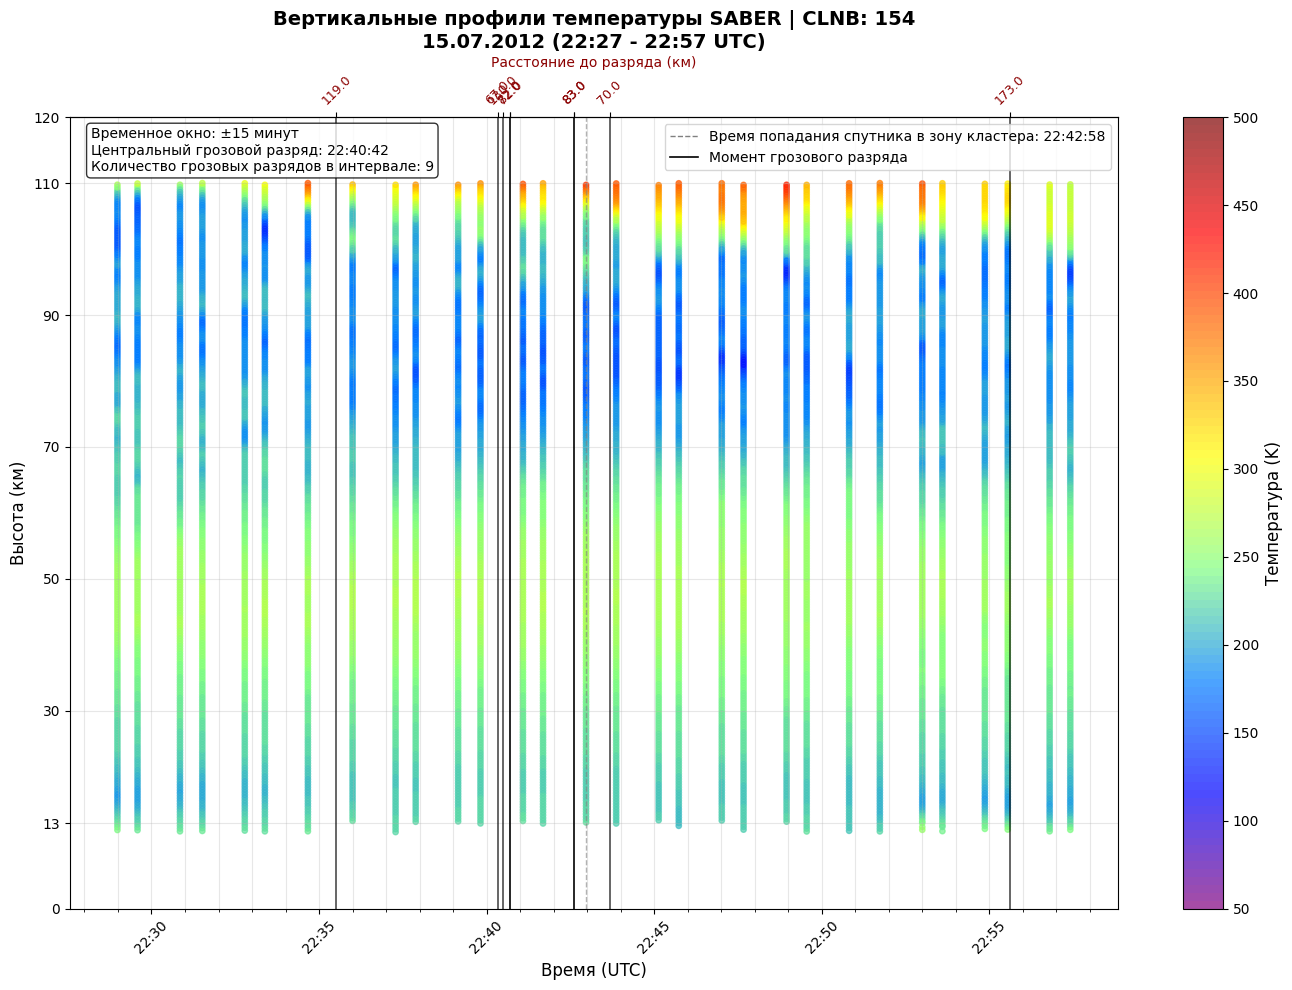

Центральная строка: 23
Высота в диапазоне: 11.6 - 110.0 км
Температура в диапазоне: 125.9 - 419.0 K


In [17]:
# Получаем дату из ds_v2_07
date_value = yyddd_to_date(ds_v2_07['date'].values[0])

# Создаем список для хранения всех профилей
all_profiles = []

# Проходим по строкам от (center_row - rows_before_after) до (center_row + rows_before_after)
for row_idx in range(center_row - rows_before_after, center_row + rows_before_after + 1):
    # Проверяем, что индекс строки в пределах допустимого
    if 0 <= row_idx < len(ds_v2_07['ktemp']):
        # Получаем температуру для текущей строки и удаляем NaN
        temp_series = pd.DataFrame(ds_v2_07['ktemp']).iloc[row_idx].dropna()
        
        if len(temp_series) > 0:  # Проверяем, есть ли данные
            valid_indices = temp_series.index
            
            # Получаем время для этой строки
            time_ms = pd.DataFrame(ds_v2_07['time']).iloc[row_idx].loc[valid_indices].values
            time_timedelta = pd.to_timedelta(time_ms, unit='ms')
            
            # Вычисляем среднее время для этого профиля
            profile_datetime = date_value + pd.to_timedelta(np.nanmean(time_ms), unit='ms')
            
            # Создаем DataFrame для текущего профиля
            profile_df = pd.DataFrame({
                'row_index': row_idx,
                'datetime': pd.Timestamp(profile_datetime).floor('s'),  # Конвертируем в Timestamp и округляем
                'latitude_deg': pd.DataFrame(ds_v2_07['tplatitude']).iloc[row_idx].loc[valid_indices].values,
                'longitude_deg': pd.DataFrame(ds_v2_07['tplongitude']).iloc[row_idx].loc[valid_indices].values,
                'altitude_km': pd.DataFrame(ds_v2_07['tpaltitude']).iloc[row_idx].loc[valid_indices].values,
                'temperature_K': temp_series.values
            })
            
            # Вычисляем среднюю высоту для этого профиля (для сортировки)
            profile_df['mean_altitude'] = profile_df['altitude_km'].mean()
            
            all_profiles.append(profile_df)

# Объединяем все профили в один DataFrame
if all_profiles:
    all_profiles_df = pd.concat(all_profiles, ignore_index=True)
    
    # Находим центральный профиль
    center_profile = all_profiles_df[all_profiles_df['row_index'] == center_row]
    if not center_profile.empty:
        # Берем первое значение datetime для центрального профиля
        center_time = center_profile['datetime'].iloc[0]
    else:
        # Если центрального профиля нет, берем среднее время всех профилей
        center_time = pd.Timestamp(all_profiles_df['datetime'].mean())
    
    # Определяем временное окно ±15 минут
    time_window_start = center_time - timedelta(minutes=15)
    time_window_end = center_time + timedelta(minutes=15)
    
    # Фильтруем профили в пределах ±15 минут
    filtered_profiles_df = all_profiles_df[
        (all_profiles_df['datetime'] >= time_window_start) & 
        (all_profiles_df['datetime'] <= time_window_end)
    ]
    
    # Создаем кастомную цветовую карту
    colors = [
        (0.5, 0.0, 0.5),    # фиолетовый
        (0, 0, 1),          # синий
        (0, 0.5, 1),        # ярко-синий
        (0.5,1,0.5),        # светло-зеленый
        (1, 1, 0),          # желтый
        (1, 0.5, 0),        # оранжевый
        (1, 0, 0),          # красный
        (0.5, 0, 0)         # темно-красный
    ]
    custom_cmap = LinearSegmentedColormap.from_list("custom_coolwarm", colors, N=100)
    
    # Построение графика
    plt.figure(figsize=(14, 10))
    
    # Сортировка по времени для лучшего отображения
    filtered_profiles_df = filtered_profiles_df.sort_values('datetime')
    
    vmin, vmax = 50, 500  # Фиксированные пределы цветовой шкалы
    
    scatter = plt.scatter(filtered_profiles_df['datetime'], 
                         filtered_profiles_df['altitude_km'], 
                         c=filtered_profiles_df['temperature_K'], 
                         cmap=custom_cmap, s=15, alpha=0.7,
                         vmin=vmin, vmax=vmax)  
    ax = plt.gca()
    ax.xaxis.set_major_locator(MinuteLocator(byminute=range(0, 60, 5)))
    ax.xaxis.set_minor_locator(MinuteLocator(interval=1))
    ax.xaxis.set_major_formatter(DateFormatter('%H:%M'))
    plt.xticks(rotation=45)
    plt.axvline(x=center_time, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='gray', linestyle='--', linewidth=1,
               label=f'Время попадания спутника в зону кластера: {center_time.strftime("%H:%M:%S")}'),
        Line2D([0], [0], color='black', linestyle='-', linewidth=1.2,
               label='Момент грозового разряда')
    ]
    ax.legend(handles=legend_elements, loc='upper right')
    
    if thunderstorm_data and 'flash_times_before_and_after' in thunderstorm_data:
        flash_times = thunderstorm_data['flash_times_before_and_after']
        distances = thunderstorm_data.get('distances_to_flashes', [])
        if flash_times and len(flash_times) > 0:
            if not distances:
                distances = [0] * len(flash_times)
            min_len = min(len(flash_times), len(distances))
            
            # Верхняя ось для отображения расстояний
            ax_dist = ax.secondary_xaxis('top')
            ax_dist.set_xlabel('Расстояние до разряда (км)', fontsize=10, color='darkred')
            ax_dist.tick_params(axis='x', labelcolor='darkred')
            
            for i in range(min_len):
                flash_time_i = flash_times[i]
                distance = distances[i] if i < len(distances) else 0
                if isinstance(flash_time_i, (datetime, pd.Timestamp)):
                    plt.axvline(x=flash_time_i, color='black', linestyle='-', 
                               linewidth=1.2, alpha=0.7)
            if flash_times:
                distance_labels = []
                for i in range(min(min_len, len(distances))):
                    try:
                        label = f'{float(distances[i]):.1f}'
                    except:
                        label = f'{distances[i]}'
                    distance_labels.append(label)
                while len(distance_labels) < min_len:
                    distance_labels.append('0.0')
                ax_dist.set_xticks(flash_times[:min_len])
                ax_dist.set_xticklabels(distance_labels, rotation=45, fontsize=9)
    
    # Настройка осей
    plt.xlabel('Время (UTC)', fontsize=12)
    plt.ylabel('Высота (км)', fontsize=12)
    plt.ylim(0, 120)
    plt.yticks([0, 13, 30, 50, 70, 90, 110, 120])
    
    # Цветовая шкала 
    cbar = plt.colorbar(scatter)
    cbar.set_label('Температура (K)', fontsize=12)
    
    # Преобразование форматов для отображения заголовка
    date_str = center_time.strftime('%d.%m.%Y')
    center_time_str = center_time.strftime('%H:%M:%S')
    start_time_str = time_window_start.strftime('%H:%M')
    end_time_str = time_window_end.strftime('%H:%M')
    
    # Добавление информации в заголовок
    clnb_info = f" | CLNB: {clnb_to_plot}" if thunderstorm_data else ""
    plt.title(f"Вертикальные профили температуры SABER{clnb_info}\n{date_str} ({start_time_str} - {end_time_str} UTC)", 
              fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3, which='both', axis='both')
    
    # Информационный текст
    if thunderstorm_data:
        flash_count = len(thunderstorm_data.get('flash_times_before_and_after', []))
        central_flash_str = thunderstorm_data['flash_time'].strftime('%H:%M:%S') if thunderstorm_data.get('flash_time') else 'N/A'
        info_text = f"Временное окно: ±15 минут\nЦентральный грозовой разряд: {central_flash_str}\nКоличество грозовых разрядов в интервале: {flash_count}"
    else:
        info_text = f"Временное окно: ±15 минут"
    
    plt.annotate(info_text, xy=(0.02, 0.987), xycoords='axes fraction', 
                 fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
                 verticalalignment='top')
    plt.tight_layout()

    # Сохранение графика
    os.makedirs(output_plot_dir, exist_ok=True)
    if thunderstorm_data and clnb_to_plot:
        date_str = center_time.strftime('%Y%m%d')
        time_str = center_time.strftime('%H%M%S')
        plot_filename = f"SABER_temp_profiles_clnb{clnb_to_plot}_{date_str}_{time_str}.png"
    plot_path = os.path.join(output_plot_dir, plot_filename)
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    
    # Вывод графика
    plt.show()

    # Вывод статистической информации
    print(f"Центральная строка: {center_row}")
    print(f"Высота в диапазоне: {filtered_profiles_df['altitude_km'].min():.1f} - {filtered_profiles_df['altitude_km'].max():.1f} км")
    print(f"Температура в диапазоне: {filtered_profiles_df['temperature_K'].min():.1f} - {filtered_profiles_df['temperature_K'].max():.1f} K")